In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

from regimesense.data.fetcher import load_data_from_config
from regimesense.features.regime_features import build_feature_matrix, normalize_features
from regimesense.regime.hmm_classifier import RegimeClassifier

plt.style.use('seaborn-v0_8-whitegrid')

# Consistent colors for each regime — use these everywhere
REGIME_COLORS = {
    "bull":           "#534AB7",   # purple
    "choppy":         "#1D9E75",   # teal
    "high_vol_trend": "#EF9F27",   # amber
    "crisis":         "#E24B4A",   # red
}

print("Setup OK")

Setup OK


In [7]:
df       = load_data_from_config()
features = build_feature_matrix(df)
normed   = normalize_features(features)

# Train fresh (or load saved: clf = RegimeClassifier.load())
clf = RegimeClassifier(n_states=4, n_iter=200, random_state=42)
clf.fit(normed)

regimes = clf.predict(normed)

print("Regime counts:")
print(regimes["regime_label"].value_counts())
print("\nTransition matrix:")
print(clf.transition_matrix().round(3))

2026-03-20 15:44:05,261  INFO  Fetching SPY from 2005-01-01 to 2024-12-31 ...
2026-03-20 15:44:05,566  INFO  Fetched 5032 trading days for SPY.
2026-03-20 15:44:05,567  INFO  Computing regime features ...
2026-03-20 15:44:07,736  INFO  Feature matrix: 4972 rows (60 dropped for rolling warm-up).
2026-03-20 15:44:07,738  INFO  Training HMM: 4 states, 4972 observations, 5 features ...
2026-03-20 15:44:09,350  INFO  HMM training complete.
2026-03-20 15:44:09,351  INFO    Converged: True
2026-03-20 15:44:09,357  INFO    Log-likelihood: -25657.49
2026-03-20 15:44:09,359  INFO  
Learned feature means per state (normalized):
2026-03-20 15:44:09,362  INFO     realized_vol  autocorr_5d  rolling_sharpe  skewness  volume_momentum
0         0.190       -0.103           0.093    -0.527            0.192
1        -0.584        0.010           1.143     0.546            0.039
2         1.265        0.061          -1.370     0.221           -0.051
3        -0.443        0.033          -0.174    -0.187  

Regime counts:
regime_label
high_vol_trend    1553
bull              1270
choppy            1191
crisis             958
Name: count, dtype: int64

Transition matrix:
                choppy   bull  crisis  high_vol_trend
choppy           0.966  0.006   0.008           0.019
bull             0.015  0.975   0.000           0.010
crisis           0.010  0.000   0.978           0.012
high_vol_trend   0.008  0.016   0.007           0.969


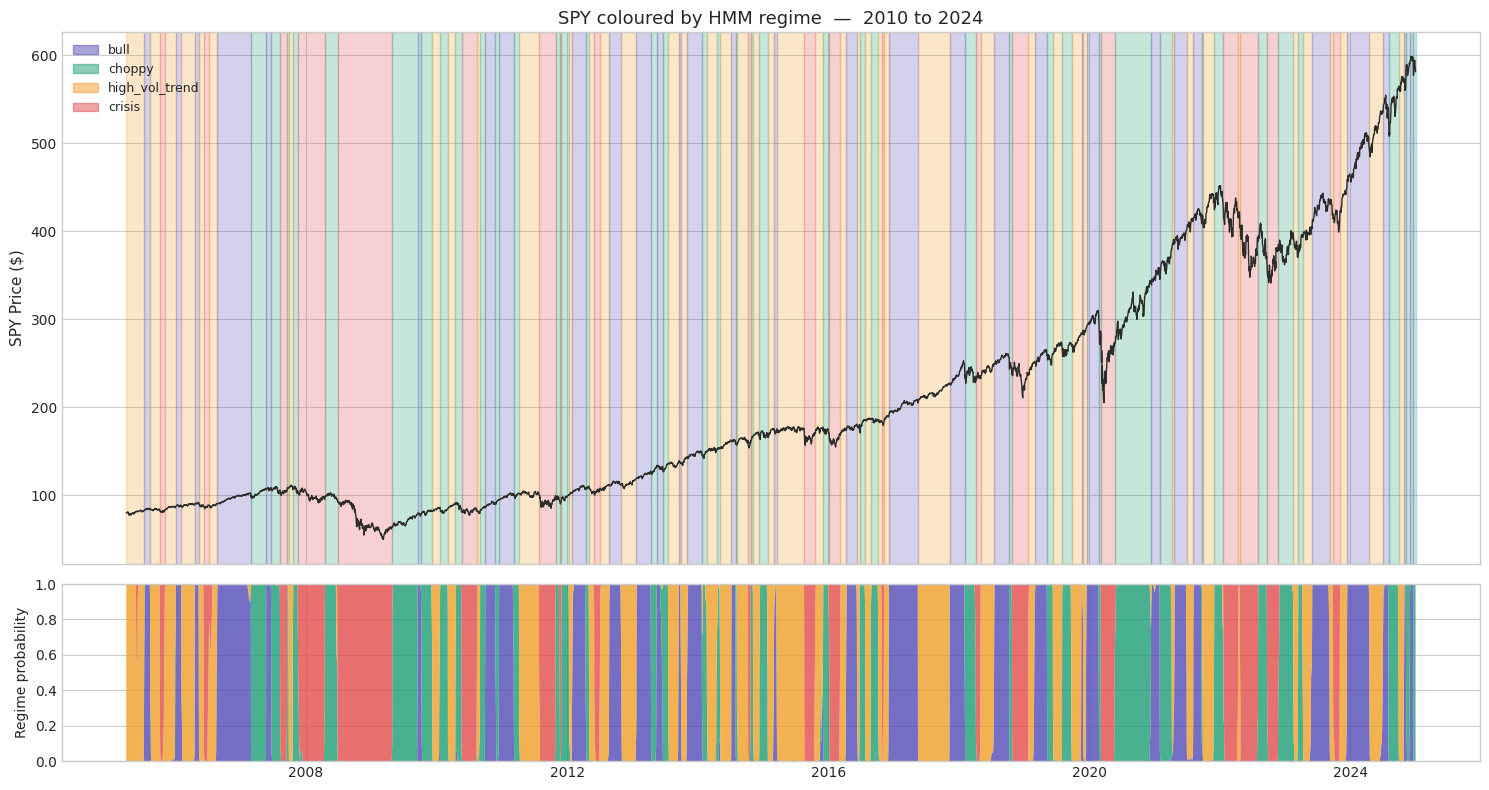

Saved → logs/regime_chart.png


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8),
                                sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# ── Top panel: SPY price with regime background shading ──
price_aligned = df['Close'].reindex(regimes.index)

# Plot price line
ax1.plot(regimes.index, price_aligned, color='#2C2C2A',
         linewidth=1, zorder=3)

# Shade background by regime
prev_date  = regimes.index[0]
prev_label = regimes['regime_label'].iloc[0]

for date, label in zip(regimes.index[1:], regimes['regime_label'][1:]):
    if label != prev_label:
        ax1.axvspan(prev_date, date,
                    alpha=0.25,
                    color=REGIME_COLORS.get(prev_label, 'gray'),
                    zorder=1)
        prev_date  = date
        prev_label = label

# Shade the last segment
ax1.axvspan(prev_date, regimes.index[-1],
            alpha=0.25,
            color=REGIME_COLORS.get(prev_label, 'gray'))

ax1.set_ylabel("SPY Price ($)", fontsize=11)
ax1.set_title("SPY coloured by HMM regime  —  2010 to 2024", fontsize=13)

# Legend
patches = [mpatches.Patch(color=c, alpha=0.5, label=r)
           for r, c in REGIME_COLORS.items()]
ax1.legend(handles=patches, loc='upper left', fontsize=9)

# ── Bottom panel: regime posterior probabilities (stacked area) ──
prob_cols = ["prob_bull", "prob_choppy", "prob_high_vol_trend", "prob_crisis"]
prob_names = ["bull", "choppy", "high_vol_trend", "crisis"]
colors     = [REGIME_COLORS[n] for n in prob_names]

ax2.stackplot(regimes.index,
              [regimes[c] for c in prob_cols],
              labels=prob_names,
              colors=colors,
              alpha=0.8)

ax2.set_ylabel("Regime probability", fontsize=10)
ax2.set_ylim(0, 1)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../logs/regime_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → logs/regime_chart.png")

In [9]:
# For each regime, compute average REALIZED return and vol
# This is the ground truth check: does "bull" actually outperform?

price_ret = df['Close'].pct_change().reindex(regimes.index)

summary = regimes.copy()
summary['daily_return'] = price_ret

grouped = summary.groupby('regime_label')['daily_return'].agg(
    mean_return=lambda x: x.mean() * 252,         # annualized
    volatility=lambda x: x.std() * np.sqrt(252),  # annualized
    sharpe=lambda x: (x.mean() / x.std()) * np.sqrt(252),
    count='count',
    pct=lambda x: len(x) / len(summary) * 100
)

print("\nRegime performance summary:")
print(grouped.round(3).to_string())
print()
print("What you want to see:")
print("  bull regime       → highest mean_return, lowest vol")
print("  crisis regime     → most negative return, highest vol")
print("  choppy            → near-zero return, low-medium vol")
print("  high_vol_trend    → moderate return, high vol")


Regime performance summary:
                mean_return  volatility  sharpe  count     pct
regime_label                                                  
bull                  0.223       0.100   2.221   1270  25.543
choppy                0.165       0.185   0.892   1191  23.954
crisis               -0.125       0.339  -0.369    958  19.268
high_vol_trend        0.148       0.106   1.393   1553  31.235

What you want to see:
  bull regime       → highest mean_return, lowest vol
  crisis regime     → most negative return, highest vol
  choppy            → near-zero return, low-medium vol
  high_vol_trend    → moderate return, high vol


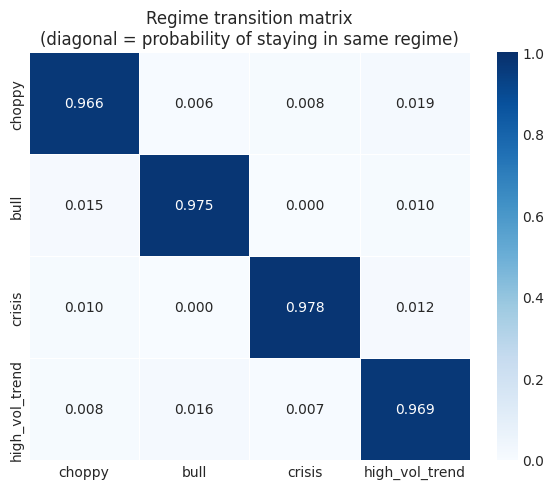


Diagonal (stickiness):
  choppy            : 0.966
  bull              : 0.975
  crisis            : 0.978
  high_vol_trend    : 0.969


In [10]:
import seaborn as sns

trans = clf.transition_matrix()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(trans, annot=True, fmt='.3f',
            cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Regime transition matrix\n"
             "(diagonal = probability of staying in same regime)")
plt.tight_layout()
plt.savefig('../logs/transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDiagonal (stickiness):")
for regime in trans.index:
    print(f"  {regime:18s}: {trans.loc[regime, regime]:.3f}")